In [1]:
import pandas as pd
from src.data_loader import data_loader

houses = data_loader()
houses_raw = houses.copy()

First I need to split set for test and train sets.

In [2]:
houses_raw['OverallQual'].describe()

count    1460.000000
mean        6.099315
std         1.382997
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: OverallQual, dtype: float64

In [3]:
import numpy as np

houses_raw["QualCat"] = pd.cut(houses_raw["OverallQual"],
                               bins=[0, 2, 4, 6, 8, 10],
                               labels=[1, 2, 3,4, 5])

<Axes: xlabel='QualCat'>

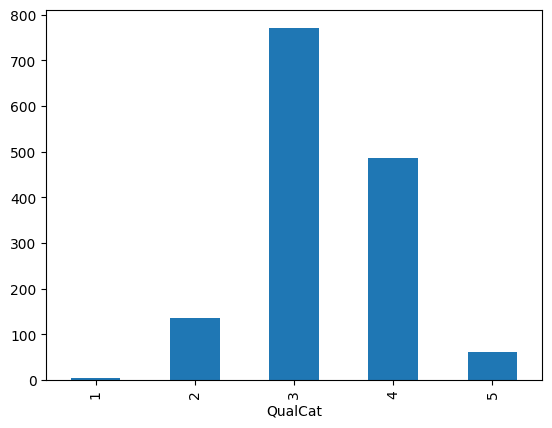

In [4]:
houses_raw['QualCat'].value_counts().sort_index(ascending=True).plot(kind='bar')

In [5]:
houses_raw['QualCat'].value_counts().sort_index()

QualCat
1      5
2    136
3    771
4    487
5     61
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(houses_raw, stratify=houses_raw['QualCat'], test_size=0.2, random_state=42)

After spliting data we have to delete 'QualCat' from our train and test sets.

In [7]:
for set_ in train_set, test_set:
    set_.drop('QualCat', axis=1, inplace=True)

In [8]:
houses_raw.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,QualCat
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,4
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,3
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,4
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,4
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,4
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000,3
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,8,2007,WD,Normal,307000,4
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,Shed,350,11,2009,WD,Normal,200000,4
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900,4
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,1,2008,WD,Normal,118000,3


We can add some features which might be helpful and make our data more descriptive.

In [9]:
houses_added_features = houses_raw.copy()
houses_added_features.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,QualCat
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,4
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,3
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,4
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,4
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,4


In [10]:
#Total area of the house
houses_added_features["TotalSF"] = houses_added_features["TotalBsmtSF"] + houses_added_features["1stFlrSF"] + houses_added_features["2ndFlrSF"]

#House age
houses_added_features["HouseAge"] = houses_added_features["YrSold"] - houses_added_features["YearBuilt"]
houses_added_features["RemodelAge"] = houses_added_features["YrSold"] - houses_added_features["YearRemodAdd"]
houses_added_features["WasRemodeled"] = (houses_added_features["YearBuilt"] != houses_added_features["YearRemodAdd"]).astype(int)

#łazienki
houses_added_features["TotalBath"] = (houses_added_features["FullBath"] +
                                       houses_added_features["HalfBath"] * 0.5 +
                                       houses_added_features["BsmtFullBath"] +
                                       houses_added_features["BsmtHalfBath"] * 0.5)

#garaż
houses_added_features["GarageAreaPerCar"] = houses_added_features["GarageArea"] / (houses_added_features["GarageCars"] + 1)

#udogodnienia
houses_added_features["HasPool"] = (houses_added_features["PoolArea"] > 0).astype(int)
houses_added_features["HasBasement"] = (houses_added_features["TotalBsmtSF"] > 0).astype(int)
houses_added_features["HasGarage"] = (houses_added_features["GarageArea"] > 0).astype(int)
houses_added_features["HasFireplace"] = (houses_added_features["Fireplaces"] > 0).astype(int)

#jakość nieruchomości
houses_added_features["QualXSF"] = houses_added_features["OverallQual"] * houses_added_features["GrLivArea"]

In [11]:
houses_added_features[["TotalSF","HouseAge","RemodelAge","WasRemodeled","TotalBath","GarageAreaPerCar","HasPool","HasBasement","HasGarage","HasFireplace","QualXSF"]]

,TotalSF,HouseAge,RemodelAge,WasRemodeled,TotalBath,GarageAreaPerCar,HasPool,HasBasement,HasGarage,HasFireplace,QualXSF
0,2566,5,5,0,3.5,182.666667,0,1,1,0,11970
1,2524,31,31,0,2.5,153.333333,0,1,1,1,7572
2,2706,7,6,1,3.5,202.666667,0,1,1,1,12502
3,2473,91,36,1,2.0,160.500000,0,1,1,1,12019
4,3343,8,8,0,3.5,209.000000,0,1,1,1,17584
...,...,...,...,...,...,...,...,...,...,...,...
1455,2600,8,7,1,2.5,153.333333,0,1,1,1,9882
1456,3615,32,22,1,3.0,166.666667,0,1,1,1,12438
1457,3492,69,4,1,2.0,126.000000,0,1,1,1,16380
1458,2156,60,14,1,2.0,120.000000,0,1,1,0,5390


<Axes: ylabel='None'>

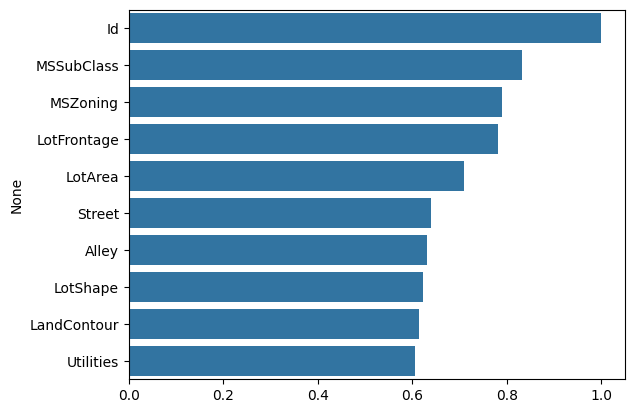

In [12]:

import seaborn as sns

corr_matrix = houses_added_features.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
sns.barplot(x = corr_matrix.values[:10], y = houses_added_features.columns[:10])


Now I am imputing NaN values. Form 01_data_analize I know which columns has numeric and string values.



<class 'pandas.DataFrame'>


RangeIndex: 1460 entries, 0 to 1459


 #   Column        Non-Null Count  Dtype


---  ------        --------------  -----


 0   PoolQC        7 non-null      str


 1   MiscFeature   54 non-null     str


 2   Alley         91 non-null     str


 3   Fence         281 non-null    str


 4   MasVnrType    588 non-null    str


 5   FireplaceQu   770 non-null    str


 6   LotFrontage   1201 non-null   float64


 7   GarageType    1379 non-null   str


 8   GarageFinish  1379 non-null   str


 9   GarageYrBlt   1379 non-null   float64


dtypes: float64(2), str(8)


memory usage: 114.2 KB

In [13]:
from sklearn.impute import SimpleImputer

lotFrontageImputer = SimpleImputer(fill_value= houses_raw['LotFrontage'].min(),strategy='constant')
lotFrontageImputer.fit(houses_raw[['LotFrontage']])
houses_raw['LotFrontage'] = lotFrontageImputer.transform(houses_raw[['LotFrontage']])

fast check

In [15]:
houses_raw['LotFrontage'].isnull().sum()

np.int64(0)

gitarra

In [20]:
houses_raw['GarageYrBlt'].sample(15)

166     1955.0
1131       NaN
664     2005.0
1060    2001.0
1224    2004.0
953     1969.0
262     1978.0
186     1990.0
1431    1976.0
1245    1984.0
755     1999.0
628     1969.0
525     2005.0
729     1962.0
1446    1962.0
Name: GarageYrBlt, dtype: float64

I have to transform data to avoid heavy tail distribution.

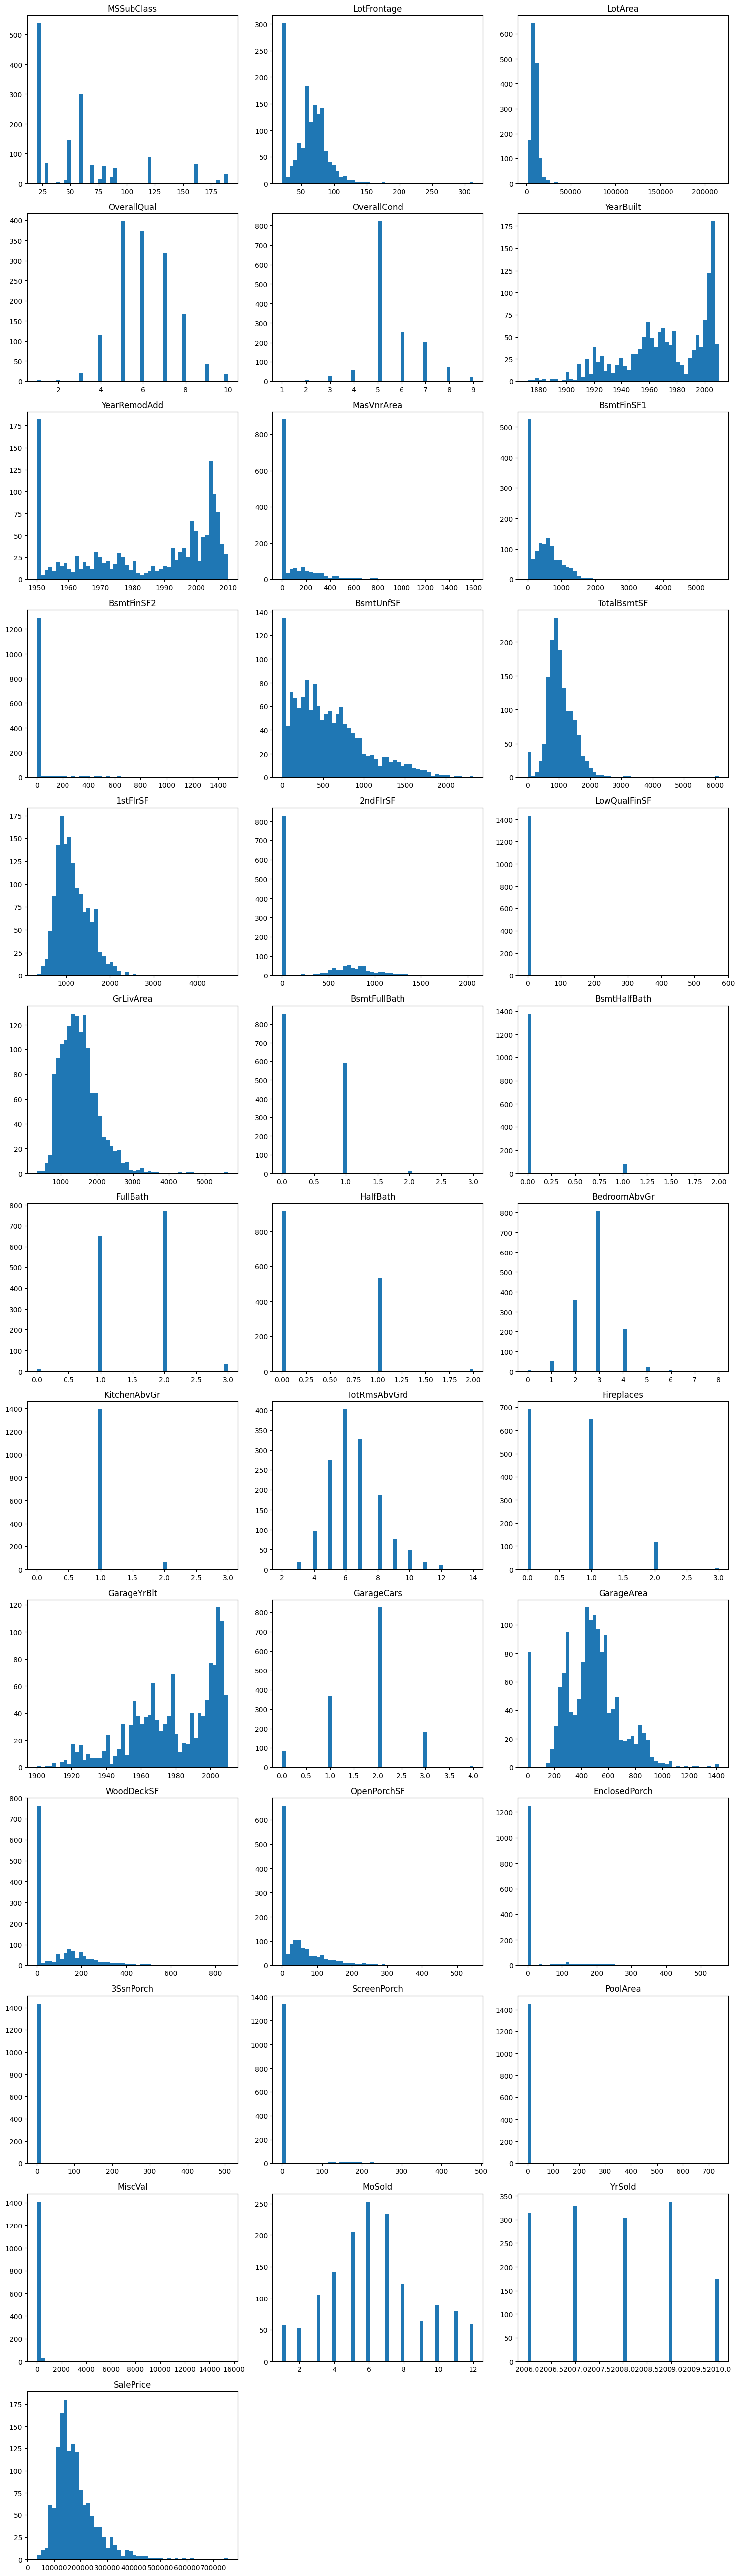

In [14]:
import math
import matplotlib.pyplot as plt

num_features = pd.DataFrame(houses_raw.select_dtypes(include=['float64', 'int64']))
num_features.drop(columns=['Id'], inplace=True)
n = len(num_features.columns)
cols = 3
rows = math.ceil(n / cols)

fig, ax = plt.subplots(rows, cols, figsize=(15, rows * 4))
ax = ax.flatten()

for i, col in enumerate(num_features.columns):
    ax[i].hist(num_features[col].dropna(), bins=50)
    ax[i].set_title(col)

for j in range(i + 1, len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()